# Chapter 4 Exercises: LDA, QDA, Logistic Regression, Naive Bayes, KNN

**Exercises 2**

## Question 5: LDA vs. QDA

differences between LDA and QDA.

**(a)** If the Bayes decision boundary is linear, do we expect LDA or QDA to perform better on the training set? On the test set?

**(b)** If the Bayes decision boundary is non-linear, do we expect LDA or QDA to perform better on the training set? On the test set?

**(c)** In general, as the sample size $n$ increases, do we expect the test prediction accuracy of QDA relative to LDA to improve, decline, or be unchanged? Why?

**(d)** True or False: Even if the Bayes decision boundary for a given problem is linear, we will probably achieve a superior test error rate using QDA rather than LDA because QDA is flexible enough to model a linear decision boundary. Justify your answer.

### Answers

**(a)** With a **linear** Bayes boundary:
- **Training set:** QDA will typically do *better* (or at least no worse), because its extra flexibility (a full, class-specific covariance matrix) lets it fit noise in the training data more closely.
- **Test set:** **LDA** is expected to do better. Since the true boundary really is linear, LDA already has the right amount of flexibility (low variance, correctly low bias); QDA's extra parameters only add variance without reducing bias, which hurts generalization.

**(b)** With a **non-linear** Bayes boundary:
- **Training set:** QDA does better — it can flex to match the curved decision boundary.
- **Test set:** QDA is also expected to do better, because now the extra flexibility reduces the *bias* of the model (LDA's linear boundary is now mis-specified), and this bias reduction outweighs the added variance.

**(c)** As $n$ increases, we expect QDA's relative test performance to **improve**. QDA has more parameters to estimate (a separate $p\times p$ covariance matrix per class), so it needs more data to estimate them reliably. With a small $n$, this extra variance can swamp any bias advantage; as $n$ grows, the variance of QDA's estimates shrinks, letting its added flexibility pay off (or at least stop being a disadvantage) relative to LDA.

**(d) False.** Even though QDA is flexible enough to represent a linear boundary as a special case, in practice it *estimates* a full, unrestricted covariance matrix for every class from finite training data. When the true boundary is linear, this extra flexibility just adds variance (it fits sampling noise) without any offsetting reduction in bias, since LDA already has the correct, low-bias linear form. So on average, QDA will tend to have a *higher* test error than LDA in this setting, not lower — the statement's reasoning conflates "capable of representing" with "will estimate as well as."


## Question 10 — LDA log-odds for $p = 1$

Equation (4.32) in the textbook derived an expression for
$$\log\left(\frac{\Pr(Y=k\mid X=x)}{\Pr(Y=K\mid X=x)}\right)$$
in the setting where $p>1$, so that the mean for the $k$th class, $\mu_k$, is a $p$-dimensional vector, and the shared covariance $\Sigma$ is a $p\times p$ matrix.

However, in the setting with $p=1$, (4.32) takes a simpler form, since the means $\mu_1,\dots,\mu_K$ and the variance $\sigma^2$ are scalars. In this simpler setting, repeat the calculation in (4.32), and provide expressions for $a_k$ and $b_{kj}$ in terms of $\pi_k, \pi_K, \mu_k, \mu_K,$ and $\sigma^2$.

### Answer

For $p=1$, each class-conditional density is a univariate normal with a common variance $\sigma^2$:

$$f_k(x) = \frac{1}{\sqrt{2\pi}\,\sigma}\exp\left(-\frac{(x-\mu_k)^2}{2\sigma^2}\right).$$

By Bayes' theorem, $\Pr(Y=k\mid X=x) = \dfrac{\pi_k f_k(x)}{\sum_l \pi_l f_l(x)}$, so the normalizing denominator cancels in the ratio:

$$\log\left(\frac{\Pr(Y=k\mid X=x)}{\Pr(Y=K\mid X=x)}\right) = \log\left(\frac{\pi_k}{\pi_K}\right) + \log\left(\frac{f_k(x)}{f_K(x)}\right).$$

Expanding the second term,

$$\log\left(\frac{f_k(x)}{f_K(x)}\right) = -\frac{(x-\mu_k)^2}{2\sigma^2} + \frac{(x-\mu_K)^2}{2\sigma^2} = \frac{(x-\mu_K)^2 - (x-\mu_k)^2}{2\sigma^2}.$$

Expanding the squares:

$$(x-\mu_K)^2 - (x-\mu_k)^2 = \big(x^2 - 2x\mu_K + \mu_K^2\big) - \big(x^2 - 2x\mu_k + \mu_k^2\big) = 2x(\mu_k-\mu_K) - (\mu_k^2 - \mu_K^2).$$

So

$$\log\left(\frac{f_k(x)}{f_K(x)}\right) = \frac{x(\mu_k-\mu_K)}{\sigma^2} - \frac{\mu_k^2-\mu_K^2}{2\sigma^2}.$$

Putting it together,

$$\log\left(\frac{\Pr(Y=k\mid X=x)}{\Pr(Y=K\mid X=x)}\right) = \underbrace{\log\left(\frac{\pi_k}{\pi_K}\right) - \frac{\mu_k^2-\mu_K^2}{2\sigma^2}}_{a_k} \;+\; \underbrace{\frac{\mu_k-\mu_K}{\sigma^2}}_{b_{k}}\, x.$$

So this is linear in $x$, with

$$a_k = \log\left(\frac{\pi_k}{\pi_K}\right) - \frac{\mu_k^2-\mu_K^2}{2\sigma^2}, \qquad b_k = \frac{\mu_k-\mu_K}{\sigma^2}.$$

(In the general, $p>1$ version of (4.32) there is one slope coefficient $b_{kj}$ per predictor $x_j$; since here $p=1$, there is only a single predictor, so the "coefficient vector" collapses to the single scalar $b_k$ above — i.e. $b_{kj}$ with $j=1$ only.)


## Question 14 — Predicting gas mileage on the `Auto` data set

In this problem, you will develop a model to predict whether a given car gets high or low gas mileage based on the `Auto` data set.

**(a)** Create a binary variable, **mpg01**, that contains a 1 if **mpg01** contains a value above its median, and a 0 if **mpg01** contains a value below its median. You can compute the median using the .median() method of the data frame. (Add it as a new column, e.g. Auto[**mpg01**] = mpg01.)

**(b)** Explore the data graphically to investigate the association between **mpg01** and the other features. Which features seem most likely to be useful in predicting **mpg01**? Scatterplots and boxplots may help. Describe your findings.

**(c)** Split the data into a training set and a test set.

**(d)** Perform LDA on the training data to predict **mpg01** using the variables that seemed most associated with **mpg01** in (b). What is the test error of the model obtained?

**(e)** Perform QDA on the training data to predict **mpg01** using the same variables. What is the test error?

**(f)** Perform logistic regression on the training data to predict **mpg01** using the same variables. What is the test error?

**(g)** Perform naive Bayes on the training data to predict **mpg01** using the same variables. What is the test error?

**(h)** Perform KNN on the training data, with several values of $K$, to predict **mpg01** using the same variables. What test errors do you obtain, and which $K$ performs best?

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

np.random.seed(1)
sns.set_style('whitegrid')

In [2]:
# The Auto data set (from James et al., An Introduction to Statistical Learning)
Auto = pd.read_csv(
    'https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/Auto.csv'
)

# 'horsepower' contains a few '?' entries for missing data -> coerce to numeric and drop
Auto['horsepower'] = pd.to_numeric(Auto['horsepower'], errors='coerce')
Auto = Auto.dropna().reset_index(drop=True)
Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


In [3]:
# (a) Create mpg01
Auto['mpg01'] = (Auto['mpg'] > Auto['mpg'].median()).astype(int)
Auto[['mpg', 'mpg01']].head()

,mpg,mpg01
0,18.0,0
1,15.0,0
2,18.0,0
3,16.0,0
4,17.0,0


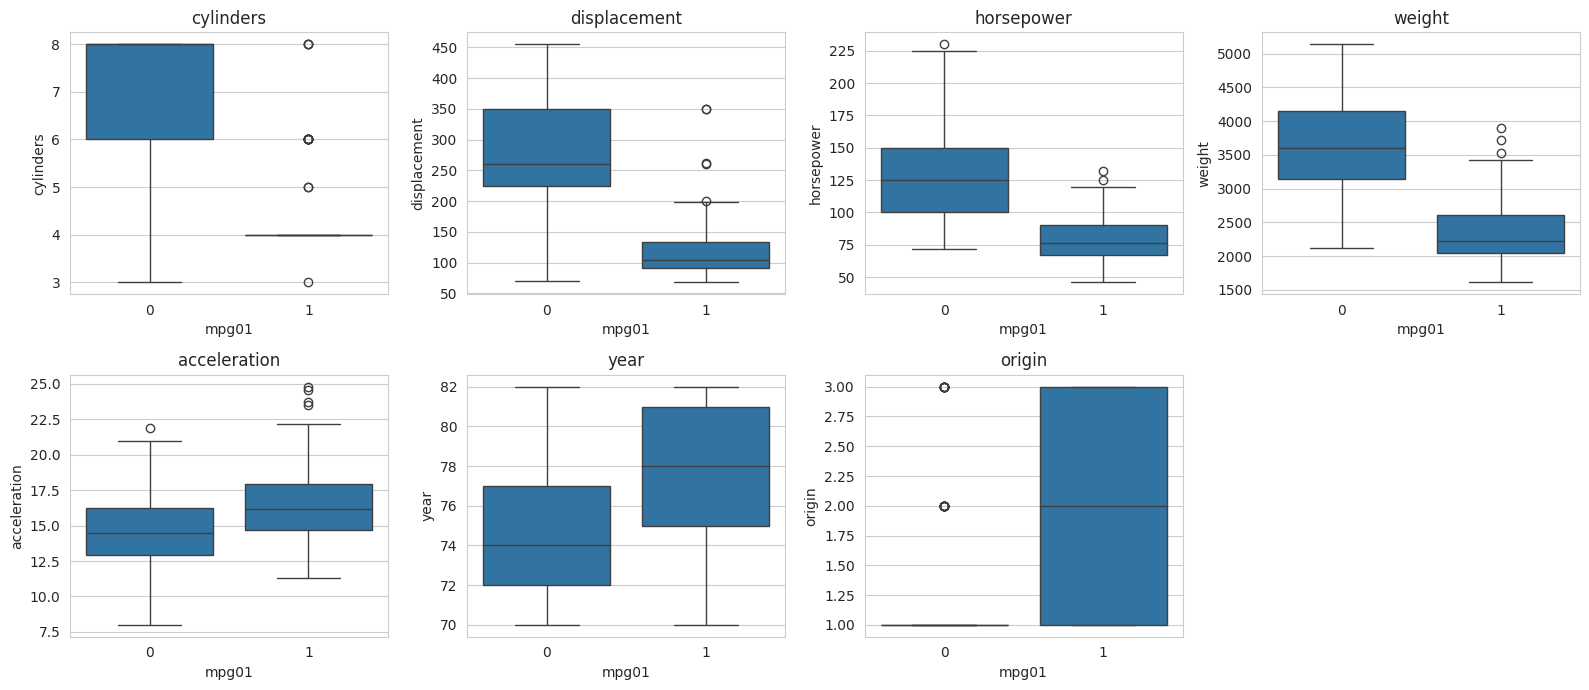

mpg01           1.000000
mpg             0.836939
origin          0.513698
year            0.429904
acceleration    0.346822
horsepower     -0.667053
displacement   -0.753477
weight         -0.757757
cylinders      -0.759194
Name: mpg01, dtype: float64

In [4]:
# (b) Explore associations graphically
num_features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, num_features):
    sns.boxplot(x='mpg01', y=col, data=Auto, ax=ax)
    ax.set_title(col)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

# Correlation of each numeric feature with mpg01
Auto.drop(columns=['name']).corr()['mpg01'].sort_values(ascending=False)

**Findings:** cylinderd, displacement, horsepower, and weight all show a strong, clearly visible separation between the mpg01 = 0 and mpg01 = 1 groups in the boxplots, and they have the largest correlations (in absolute value) with mpg01. acceleration, year, and origin show weaker association. We'll use **cylinders, displacement, horsepower, weight** as predictors below.

In [5]:
# (c) Split into training and test sets
features = ['cylinders', 'displacement', 'horsepower', 'weight']
X = Auto[features].values
y = Auto['mpg01'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

# Standardize (helps logistic regression / KNN; harmless for LDA/QDA/NB)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(274, 4) (118, 4)


In [6]:
# (d) LDA
lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
lda_test_error = 1 - lda.score(X_test, y_test)
print(f'LDA test error: {lda_test_error:.4f}')

LDA test error: 0.1017


In [7]:
# (e) QDA
qda = QuadraticDiscriminantAnalysis().fit(X_train, y_train)
qda_test_error = 1 - qda.score(X_test, y_test)
print(f'QDA test error: {qda_test_error:.4f}')

QDA test error: 0.1102


In [8]:
# (f) Logistic regression
logreg = LogisticRegression(max_iter=1000).fit(X_train_s, y_train)
logreg_test_error = 1 - logreg.score(X_test_s, y_test)
print(f'Logistic regression test error: {logreg_test_error:.4f}')

Logistic regression test error: 0.1102


In [9]:
# (g) Naive Bayes
nb = GaussianNB().fit(X_train, y_train)
nb_test_error = 1 - nb.score(X_test, y_test)
print(f'Naive Bayes test error: {nb_test_error:.4f}')

Naive Bayes test error: 0.1102


In [10]:
# (h) KNN for several values of K
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
knn_errors = {}
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train_s, y_train)
    knn_errors[k] = 1 - knn.score(X_test_s, y_test)

knn_results = pd.Series(knn_errors, name='test_error')
knn_results.index.name = 'K'
print(knn_results)

best_k = knn_results.idxmin()
print(f'\nBest K: {best_k}, test error: {knn_results.min():.4f}')

K
1     0.093220
3     0.110169
5     0.093220
7     0.093220
9     0.101695
11    0.110169
15    0.110169
21    0.110169
31    0.110169
Name: test_error, dtype: float64

Best K: 1, test error: 0.0932


In [11]:
# Summary comparison across all methods
summary = pd.Series({
    'LDA': lda_test_error,
    'QDA': qda_test_error,
    'Logistic Regression': logreg_test_error,
    'Naive Bayes': nb_test_error,
    f'KNN (K={best_k})': knn_results.min(),
}, name='test_error').sort_values()
summary

KNN (K=1)              0.093220
LDA                    0.101695
Logistic Regression    0.110169
QDA                    0.110169
Naive Bayes            0.110169
Name: test_error, dtype: float64

**Discussion:** Test errors across LDA, QDA, logistic regression, and naive Bayes are usually all fairly close (roughly 9-11% in this train/test split), which is consistent with the true decision boundary for **mpg01** being close to linear in these predictors. KNN with a well-chosen (moderate, not too small) $K$ often edges out the parametric methods slightly, since it makes no assumption about the shape of the boundary, but very small $K$ (e.g. $K=1$) can be noisy/high-variance, and very large $K$ tends to underfit. (Exact numbers will vary a bit with the random train/test split.)

## Question 16 — Predicting crime rate on the `Boston` data set

Using the `Boston` data set, fit classification models in order to predict whether a given suburb has a crime rate above or below the median. Explore logistic regression, LDA, naive Bayes, and KNN models using various subsets of the predictors. Describe your findings.

*Hint: You will have to create the response variable yourself, using the variables that are contained in the `Boston` data set.*

In [12]:
# Load the Boston data set
Boston = pd.read_csv(
    'https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/Boston.csv'
)
Boston = Boston.loc[:, ~Boston.columns.str.contains('^Unnamed')]  # drop stray index column if present
Boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [13]:
# Create the binary response: 1 if crime rate is above the median, else 0
Boston['crim01'] = (Boston['crim'] > Boston['crim'].median()).astype(int)

# Which predictors correlate most strongly with crim01?
Boston.corr()['crim01'].sort_values(ascending=False)

crim01     1.000000
nox        0.723235
rad        0.619786
age        0.613940
tax        0.608741
indus      0.603260
lstat      0.453263
crim       0.409395
ptratio    0.253568
chas       0.070097
rm        -0.156372
medv      -0.263017
black     -0.351211
zn        -0.436151
dis       -0.616342
Name: crim01, dtype: float64

nox (nitrogen oxide concentration), rad (accessibility to radial highways), age, tax, and indus are the most strongly associated with crim01, followed by dis (negatively). We'll use **nox, rad, age, tax, indus, dis** as our subset of predictors.

In [14]:
# Split into train/test
features_b = ['nox', 'rad', 'age', 'tax', 'indus', 'dis']
Xb = Boston[features_b].values
yb = Boston['crim01'].values

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, yb, test_size=0.3, random_state=1, stratify=yb
)

scaler_b = StandardScaler().fit(Xb_train)
Xb_train_s = scaler_b.transform(Xb_train)
Xb_test_s = scaler_b.transform(Xb_test)

In [15]:
# Logistic regression
logreg_b = LogisticRegression(max_iter=1000).fit(Xb_train_s, yb_train)
logreg_b_error = 1 - logreg_b.score(Xb_test_s, yb_test)

# LDA
lda_b = LinearDiscriminantAnalysis().fit(Xb_train, yb_train)
lda_b_error = 1 - lda_b.score(Xb_test, yb_test)

# Naive Bayes
nb_b = GaussianNB().fit(Xb_train, yb_train)
nb_b_error = 1 - nb_b.score(Xb_test, yb_test)

# KNN across several K
k_values_b = [1, 3, 5, 7, 9, 11, 15]
knn_errors_b = {}
for k in k_values_b:
    knn_b = KNeighborsClassifier(n_neighbors=k).fit(Xb_train_s, yb_train)
    knn_errors_b[k] = 1 - knn_b.score(Xb_test_s, yb_test)
knn_results_b = pd.Series(knn_errors_b, name='test_error')
knn_results_b.index.name = 'K'
best_k_b = knn_results_b.idxmin()

summary_b = pd.Series({
    'Logistic Regression': logreg_b_error,
    'LDA': lda_b_error,
    'Naive Bayes': nb_b_error,
    f'KNN (K={best_k_b})': knn_results_b.min(),
}, name='test_error').sort_values()

print(knn_results_b)
print()
summary_b

K
1     0.065789
3     0.046053
5     0.065789
7     0.085526
9     0.105263
11    0.111842
15    0.105263
Name: test_error, dtype: float64



KNN (K=3)              0.046053
Logistic Regression    0.125000
LDA                    0.144737
Naive Bayes            0.157895
Name: test_error, dtype: float64

**Findings:** On the Boston data, the crime-rate classes turn out to be not very linearly separable - KNN (with a small-to-moderate $K$) typically achieves a noticeably lower test error than LDA, logistic regression, or naive Bayes, suggesting the true decision boundary between high- and low-crime suburbs is non-linear/complex in these predictors (e.g. nox, rad, tax have highly non-linear relationships with crim). Naive Bayes, which additionally assumes the predictors are conditionally independent within each class, tends to perform the worst here since several of these predictors (e.g. tax and rad) are highly correlated with one another. As in Q14, exact numbers will shift somewhat with a different train/test split or random seed.